In [3]:
## 第一步：环境检查和库导入
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    get_linear_schedule_with_warmup
)



from tqdm.auto import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 下载 NLTK 数据
nltk.download('punkt', quiet=True)

True

In [4]:
# 设置路径
DATA_DIR = '../../data/DuReaderQG/'
OUTPUT_DIR = './my_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, 'train.json')
DEV_FILE = os.path.join(DATA_DIR, 'dev.json')

# 检查数据文件
print(f"训练数据: {TRAIN_FILE}")
print(f"  存在: {os.path.exists(TRAIN_FILE)}")
if os.path.exists(TRAIN_FILE):
    print(f"  大小: {os.path.getsize(TRAIN_FILE) / 1024 / 1024:.1f} MB")

print(f"\n验证数据: {DEV_FILE}")
print(f"  存在: {os.path.exists(DEV_FILE)}")
if os.path.exists(DEV_FILE):
    print(f"  大小: {os.path.getsize(DEV_FILE) / 1024 / 1024:.1f} MB")

print(f"\n输出目录: {OUTPUT_DIR}")

训练数据: ../../data/DuReaderQG/train.json
  存在: True
  大小: 11.9 MB

验证数据: ../../data/DuReaderQG/dev.json
  存在: True
  大小: 0.8 MB

输出目录: ./my_output/


In [5]:
class QADataset(Dataset):
    """生成式问答数据集

    数据格式 (JSON Lines):
    {"context": "...", "question": "...", "answer": "...", "id": 0}
    """

    def __init__(self, data_file, tokenizer, max_input_length=512, max_target_length=64):
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length
        self.data = self.load_data(data_file)

    def load_data(self, data_file):
        """加载 JSON Lines 数据"""
        data = []
        with open(data_file, 'r', encoding='utf-8') as f:
            for line in f:
                sample = json.loads(line.strip())
                data.append(sample)
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        context = sample['context']
        question = sample['question']
        answer = sample['answer']

        # T5 输入格式："question: {Q} context: {C}"
        input_text = f"question: {question} context: {context}"

        # 编码输入
        inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # 编码目标（答案）
        targets = self.tokenizer(
            answer,
            max_length=self.max_target_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'labels': targets['input_ids'].squeeze(),
            'decoder_attention_mask': targets['attention_mask'].squeeze(),
            'question': question,
            'context': context,
            'answer': answer
        }

print("✓ QADataset 类定义成功")

✓ QADataset 类定义成功


In [9]:
MODEL_CHOICE='./mengzi-t5-base'
model_name = MODEL_CHOICE
tokenizer_name = MODEL_CHOICE
print(f"\n加载 T5 分词器: {tokenizer_name}...")
tokenizer = T5Tokenizer.from_pretrained(tokenizer_name, model_max_length=512)
print("✓ 分词器加载成功")

print("\n加载训练集...")
train_dataset = QADataset(TRAIN_FILE, tokenizer, max_input_length=512, max_target_length=64)
print(f"✓ 加载 {len(train_dataset)} 条训练数据")

print("\n加载验证集...")
dev_dataset = QADataset(DEV_FILE, tokenizer, max_input_length=512, max_target_length=64)
print(f"✓ 加载 {len(dev_dataset)} 条验证数据")


加载 T5 分词器: ./mengzi-t5-base...
✓ 分词器加载成功

加载训练集...
✓ 加载 14520 条训练数据

加载验证集...
✓ 加载 984 条验证数据


In [10]:
# 查看前 3 条样本
for i in range(3):
    sample = train_dataset[i]
    print(f"\n=== 样本 {i+1} ===")
    print(f"问题: {sample['question']}")
    print(f"文章: {sample['context'][:150]}...")
    print(f"答案: {sample['answer']}")
    print(f"输入 ID 形状: {sample['input_ids'].shape}")


=== 样本 1 ===
问题: 仙剑奇侠传3第几集上天界
文章: 第35集雪见缓缓张开眼睛，景天又惊又喜之际，长卿和紫萱的仙船驶至，见众人无恙，也十分高兴。众人登船，用尽合力把自身的真气和水分输给她。雪见终于醒过来了，但却一脸木然，全无反应。众人向常胤求助，却发现人世界竟没有雪见的身世纪录。长卿询问清微的身世，清微语带双关说一切上了天界便有答案。长卿驾驶仙船，众人...
答案: 第35集
输入 ID 形状: torch.Size([512])

=== 样本 2 ===
问题: 燃气热水器哪个牌子好
文章: 选择燃气热水器时，一定要关注这几个问题：1、出水稳定性要好，不能出现忽热忽冷的现象2、快速到达设定的需求水温3、操作要智能、方便4、安全性要好，要装有安全报警装置 市场上燃气热水器品牌众多，购买时还需多加对比和仔细鉴别。方太今年主打的磁化恒温热水器在使用体验方面做了全面升级：9秒速热，可快速进入洗浴...
答案: 方太
输入 ID 形状: torch.Size([512])

=== 样本 3 ===
问题: 乔丹打了多少个赛季
文章: 迈克尔.乔丹在NBA打了15个赛季。他在84年进入nba，期间在1993年10月6日第一次退役改打棒球，95年3月18日重新回归，在99年1月13日第二次退役，后于2001年10月31日复出，在03年最终退役。迈克尔·乔丹（Michael Jordan），1963年2月17日生于纽约布鲁克林，美国著...
答案: 15个
输入 ID 形状: torch.Size([512])


In [11]:
# 超参数配置
hyperparams = {
    'learning_rate': 2e-5,
    'num_epochs': 3,
    'batch_size': 8,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0,
    'seed': 42
}

# 设置随机种子
random.seed(hyperparams['seed'])
np.random.seed(hyperparams['seed'])
torch.manual_seed(hyperparams['seed'])

print("超参数配置:")
for k, v in hyperparams.items():
    print(f"  {k}: {v}")

超参数配置:
  learning_rate: 2e-05
  num_epochs: 3
  batch_size: 8
  warmup_ratio: 0.1
  weight_decay: 0.01
  max_grad_norm: 1.0
  seed: 42


In [12]:
# 设置设备
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"✓ 设备: {device}")

✓ 设备: mps


In [13]:
print("创建 DataLoader...")
train_loader = DataLoader(train_dataset, batch_size=hyperparams['batch_size'], shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=hyperparams['batch_size'], shuffle=False)

print(f"✓ 训练集批次数: {len(train_loader)}")
print(f"✓ 验证集批次数: {len(dev_loader)}")
print(f"✓ 单个 batch 大小: {hyperparams['batch_size']}")

创建 DataLoader...
✓ 训练集批次数: 1815
✓ 验证集批次数: 123
✓ 单个 batch 大小: 8


In [14]:
print(f"加载 T5 模型: {model_name}...")
model = T5ForConditionalGeneration.from_pretrained(model_name)
model = model.to(device)

print(f"✓ 模型加载成功")
print(f"✓ 模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"✓ 模型所在设备: {next(model.parameters()).device}")

加载 T5 模型: ./mengzi-t5-base...


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✓ 模型加载成功
✓ 模型参数量: 247.6M
✓ 模型所在设备: mps:0


In [15]:
# 优化器
optimizer = AdamW(
    model.parameters(),
    lr=hyperparams['learning_rate'],
    weight_decay=hyperparams['weight_decay']
)

# 学习率调度器
total_steps = len(train_loader) * hyperparams['num_epochs']
warmup_steps = int(total_steps * hyperparams['warmup_ratio'])
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"优化器: AdamW")
print(f"  学习率: {hyperparams['learning_rate']}")
print(f"  权重衰减: {hyperparams['weight_decay']}")
print(f"\n学习率调度器: Linear with Warmup")
print(f"  总步数: {total_steps}")
print(f"  预热步数: {warmup_steps}")

优化器: AdamW
  学习率: 2e-05
  权重衰减: 0.01

学习率调度器: Linear with Warmup
  总步数: 5445
  预热步数: 544


In [16]:
def calculate_bleu(predictions, references, n_gram=4):
    """计算 BLEU 分数"""
    smoothing_function = SmoothingFunction().method1
    bleu_scores = {f'BLEU-{i}': [] for i in range(1, n_gram + 1)}

    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = ref.split()

        for i in range(1, n_gram + 1):
            weights = tuple([1.0 / i] * i)
            score = sentence_bleu(
                [ref_tokens],
                pred_tokens,
                weights=weights,
                smoothing_function=smoothing_function
            )
            bleu_scores[f'BLEU-{i}'].append(score)

    avg_bleu = {k: np.mean(v) for k, v in bleu_scores.items()}
    return avg_bleu

print("✓ BLEU 计算函数定义成功")

✓ BLEU 计算函数定义成功


In [17]:
def train_epoch(model, train_loader, optimizer, scheduler, device):
    """训练一个 epoch"""
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), hyperparams['max_grad_norm'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)
    return avg_loss

print("✓ train_epoch 函数定义成功")

✓ train_epoch 函数定义成功


In [18]:
def evaluate(model, dev_loader, device, tokenizer, max_length=64):
    """在验证集上评估"""
    model.eval()
    total_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for batch in tqdm(dev_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=max_length,
                num_beams=4,
                early_stopping=True
            )

            preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            refs = batch['answer']

            predictions.extend(preds)
            references.extend(refs)

    avg_loss = total_loss / len(dev_loader)
    bleu_scores = calculate_bleu(predictions, references)

    return avg_loss, bleu_scores, predictions, references

print("✓ evaluate 函数定义成功")

✓ evaluate 函数定义成功


In [22]:
# 记录训练历史
training_history = {
    'train_loss': [],
    'dev_loss': [],
    'dev_bleu1': [],
    'dev_bleu2': [],
    'dev_bleu3': [],
    'dev_bleu4': []
}

best_bleu = 0
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

print("开始训练...\n")
for epoch in range(hyperparams['num_epochs']):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{hyperparams['num_epochs']}")
    print(f"{'='*60}")

    # 训练
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"\n训练损失: {train_loss:.4f}")
    training_history['train_loss'].append(train_loss)

    # 验证
    dev_loss, bleu_scores, predictions, references = evaluate(model, dev_loader, device, tokenizer)
    print(f"\n验证损失: {dev_loss:.4f}")
    print("验证 BLEU 分数:")
    for k, v in bleu_scores.items():
        print(f"  {k}: {v:.4f}")

    # 记录历史
    training_history['dev_loss'].append(dev_loss)
    training_history['dev_bleu1'].append(bleu_scores['BLEU-1'])
    training_history['dev_bleu2'].append(bleu_scores['BLEU-2'])
    training_history['dev_bleu3'].append(bleu_scores['BLEU-3'])
    training_history['dev_bleu4'].append(bleu_scores['BLEU-4'])

    # 保存最佳模型
    if bleu_scores['BLEU-2'] > best_bleu:
        best_bleu = bleu_scores['BLEU-2']
        torch.save(model.state_dict(), best_model_path)
        print(f"\n✓ 保存最佳模型 (BLEU-2: {best_bleu:.4f})")

print("\n" + "="*60)
print("✅ 训练完成！")
print("="*60)

开始训练...


Epoch 1/3


Training:   0%|          | 0/1815 [00:00<?, ?it/s]


训练损失: 0.0194


Evaluating:   0%|          | 0/123 [00:00<?, ?it/s]


验证损失: 0.0713
验证 BLEU 分数:
  BLEU-1: 0.4720
  BLEU-2: 0.1493
  BLEU-3: 0.1017
  BLEU-4: 0.0839

✓ 保存最佳模型 (BLEU-2: 0.1493)

Epoch 2/3


...


验证损失: 0.0713
验证 BLEU 分数:
  BLEU-1: 0.4720
  BLEU-2: 0.1493
  BLEU-3: 0.1017
  BLEU-4: 0.0839

Epoch 3/3


Training:   0%|          | 0/1815 [00:00<?, ?it/s]


训练损失: 0.0160


Evaluating:   0%|          | 0/123 [00:00<?, ?it/s]


验证损失: 0.0713
验证 BLEU 分数:
  BLEU-1: 0.4720
  BLEU-2: 0.1493
  BLEU-3: 0.1017
  BLEU-4: 0.0839

✅ 训练完成！


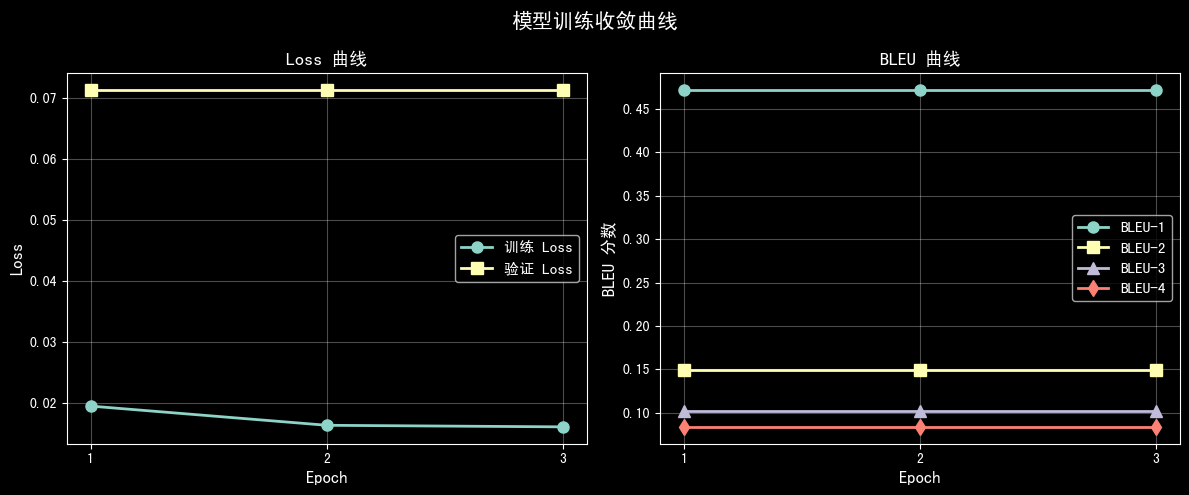

✓ 曲线已保存到 ./my_output/training_curves.png


In [24]:
# 绘制训练曲线（Loss 和 BLEU 两张独立子图）
epochs = range(1, hyperparams['num_epochs'] + 1)

fig, (ax_loss, ax_bleu) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('模型训练收敛曲线', fontsize=15, fontweight='bold')

# 左图：Loss
ax_loss.plot(epochs, training_history['train_loss'], label='训练 Loss', marker='o', linewidth=2, markersize=8)
ax_loss.plot(epochs, training_history['dev_loss'],   label='验证 Loss', marker='s', linewidth=2, markersize=8)
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12)
ax_loss.set_title('Loss 曲线', fontsize=13, fontweight='bold')
ax_loss.set_xticks(epochs)
ax_loss.legend(fontsize=11)
ax_loss.grid(True, alpha=0.3)

# 右图：BLEU-1/2/3/4 全部画在一张图方便对比
markers = ['o', 's', '^', 'd']
for n, marker in zip(range(1, 5), markers):
    ax_bleu.plot(epochs, training_history[f'dev_bleu{n}'],
                 label=f'BLEU-{n}', marker=marker, linewidth=2, markersize=8)
ax_bleu.set_xlabel('Epoch', fontsize=12)
ax_bleu.set_ylabel('BLEU 分数', fontsize=12)
ax_bleu.set_title('BLEU 曲线', fontsize=13, fontweight='bold')
ax_bleu.set_xticks(epochs)
ax_bleu.legend(fontsize=11)
ax_bleu.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 曲线已保存到 {OUTPUT_DIR}training_curves.png")

In [25]:
# 加载最佳模型
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print(f"✓ 加载最佳模型")
print(f"✓ 模型路径: {best_model_path}")

✓ 加载最佳模型
✓ 模型路径: ./my_output/best_model.pt


In [28]:
def predict_answer(question, context, model, tokenizer, device, max_length=64):
    """生成式问答预测函数"""
    # 构造输入
    input_text = f"question: {question} context: {context}"

    # 编码输入
    inputs = tokenizer(
        input_text,
        max_length=512,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    # 生成答案
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=max_length,
            num_beams=4,
            early_stopping=True,
            # temperature=0.9,
            # top_p=0.95
        )

    # 解码答案
    answer = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return answer

print("✓ 预测函数定义成功")

✓ 预测函数定义成功


In [29]:
# 测试预测 - 验证集的前 5 个样本
print("\n" + "="*80)
print("验证集上的预测示例 (前 5 个样本)")
print("="*80)

for i in range(min(5, len(dev_dataset))):
    sample = dev_dataset[i]
    question = sample['question']
    context = sample['context']
    ground_truth = sample['answer']

    # 预测
    prediction = predict_answer(question, context, model, tokenizer, device)

    # 计算 BLEU
    bleu_scores = calculate_bleu([prediction], [ground_truth])

    print(f"\n示例 {i + 1}:")
    print(f"❓ 问题: {question}")
    print(f"📄 文章: {context[:100]}...")
    print(f"✓ 参考答案: {ground_truth}")
    print(f"🤖 预测答案: {prediction}")
    print(f"📊 BLEU-1: {bleu_scores['BLEU-1']:.4f} | BLEU-2: {bleu_scores['BLEU-2']:.4f}")
    print("-" * 80)


验证集上的预测示例 (前 5 个样本)

示例 1:
❓ 问题: 2017年银行贷款基准利率
📄 文章: 年基准利率4.35%。 从实际看,贷款的基本条件是: 一是中国大陆居民,年龄在60岁以下; 二是有稳定的住址和工作或经营地点; 三是有稳定的收入来源; 四是无不良信用记录,贷款用途不能作为炒股,赌博等...
✓ 参考答案: 年基准利率4.35%
🤖 预测答案: 4.35%
📊 BLEU-1: 0.0000 | BLEU-2: 0.0000
--------------------------------------------------------------------------------

示例 2:
❓ 问题: 2017年银行贷款基准利率
📄 文章: 年基准利率4.35%。 从实际看,贷款的基本条件是: 一是中国大陆居民,年龄在60岁以下; 二是有稳定的住址和工作或经营地点; 三是有稳定的收入来源; 四是无不良信用记录,贷款用途不能作为炒股,赌博等...
✓ 参考答案: 4.35%
🤖 预测答案: 4.35%
📊 BLEU-1: 1.0000 | BLEU-2: 0.3162
--------------------------------------------------------------------------------

示例 3:
❓ 问题: 格力空调哪个系列好
📄 文章: U系列是最好的，采用国际顶尖技术（由格力自主研发）双级变频压缩机，提高压缩机运转效率，制冷制热能力更强劲；1赫兹变频技术，使空调相当于一个15 W电灯泡，更加节能省电；送风面积广，风力大；生态风，净化...
✓ 参考答案: U系列
🤖 预测答案: U系列
📊 BLEU-1: 1.0000 | BLEU-2: 0.3162
--------------------------------------------------------------------------------

示例 4:
❓ 问题: 橱柜宽度
📄 文章: 平面操作区域进深（即宽度）以40至60厘米为宜；要充分考虑洗菜盆的宽度。以标准洗菜盆来算，应选择550－－600MM的宽度为好。另：在高度方面，根据我国人体高度测算，掌握以下尺寸为宜：操作台高度在89...
✓ 参考答案: 以40至60

In [30]:
# 自定义输入预测
print("\n" + "="*80)
print("自定义输入预测示例")
print("="*80)

# 示例 1
question1 = "什么时候清零?"
context1 = "淘宝网每年12月31日24:00点会对符合条件的扣分做清零处理。"
print(f"\n示例 1:")
print(f"❓ 问题: {question1}")
print(f"📄 文章: {context1}")
pred1 = predict_answer(question1, context1, model, tokenizer, device)
print(f"🤖 答案: {pred1}")

# 示例 2
question2 = "这个产品的主要特点是什么?"
context2 = "iPhone 15 采用了新一代 A17 Pro 芯片，支持 USB-C 接口，配备了更先进的相机系统，续航能力提升至 26 小时。"
print(f"\n示例 2:")
print(f"❓ 问题: {question2}")
print(f"📄 文章: {context2}")
pred2 = predict_answer(question2, context2, model, tokenizer, device)
print(f"🤖 答案: {pred2}")

# 示例 3
question3 = "中国的首都是哪里?"
context3 = "北京是中华人民共和国的首都，是全国的政治、文化、国际交往中心，也是中国历史文化名城。"
print(f"\n示例 3:")
print(f"❓ 问题: {question3}")
print(f"📄 文章: {context3}")
pred3 = predict_answer(question3, context3, model, tokenizer, device)
print(f"🤖 答案: {pred3}")

print("\n" + "="*80)


自定义输入预测示例

示例 1:
❓ 问题: 什么时候清零?
📄 文章: 淘宝网每年12月31日24:00点会对符合条件的扣分做清零处理。
🤖 答案: 12月31日24:00

示例 2:
❓ 问题: 这个产品的主要特点是什么?
📄 文章: iPhone 15 采用了新一代 A17 Pro 芯片，支持 USB-C 接口，配备了更先进的相机系统，续航能力提升至 26 小时。
🤖 答案: iPhone 15

示例 3:
❓ 问题: 中国的首都是哪里?
📄 文章: 北京是中华人民共和国的首都，是全国的政治、文化、国际交往中心，也是中国历史文化名城。
🤖 答案: 北京



In [31]:
# 保存分词器和模型
model_save_path = os.path.join(OUTPUT_DIR, 'final_model')
os.makedirs(model_save_path, exist_ok=True)

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✓ 模型已保存到: {model_save_path}")
print(f"✓ 包含文件: pytorch_model.bin, config.json, tokenizer.json 等")

# 保存超参数
with open(os.path.join(OUTPUT_DIR, 'hyperparams.json'), 'w') as f:
    json.dump(hyperparams, f, indent=2)
print(f"✓ 超参数已保存到: {os.path.join(OUTPUT_DIR, 'hyperparams.json')}")

# 保存训练历史
with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(training_history, f, indent=2)
print(f"✓ 训练历史已保存到: {os.path.join(OUTPUT_DIR, 'training_history.json')}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ 模型已保存到: ./my_output/final_model
✓ 包含文件: pytorch_model.bin, config.json, tokenizer.json 等
✓ 超参数已保存到: ./my_output/hyperparams.json
✓ 训练历史已保存到: ./my_output/training_history.json
